<a href="https://colab.research.google.com/github/eerenkurt/ml-studies/blob/main/16-time-series-forecasting/btc_price_prediction_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install fbprophet

  Using cached fbprophet-0.7.1.tar.gz (64 kB)
  Preparing metadata (setup.py) ... done
  Using cached cmdstanpy-0.9.5-py3-none-any.whl.metadata (2.9 kB)
  Using cached pystan-3.10.1-py3-none-any.whl.metadata (3.6 kB)
  Using cached LunarCalendar-0.0.9-py2.py3-none-any.whl.metadata (6.3 kB)
  Using cached convertdate-2.4.1-py3-none-any.whl.metadata (9.7 kB)
  Using cached setuptools_git-1.2-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached PyMeeus-0.5.12-py3-none-any.whl
  Using cached ephem-4.2.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.3 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
  Using cached httpstan-4.13.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pysimdjson-7.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.1 kB)
  Using cached crashtest-0.3.1-py3-none-any.whl.metadata (748 bytes)
  Using cached pastel-0.2.1-py2.py3-none-a

In [22]:
!pip install yfinance

In [23]:
from prophet import Prophet
import yfinance as yf

In [59]:
df = yf.download('BTC-USD','2015-01-01','2026-05-12')

/tmp/ipykernel_11033/744958359.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD','2015-01-01','2026-05-12')
[*********************100%***********************]  1 of 1 completed


In [60]:
df.head(3)

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400


In [61]:
df = df[['Close']]

In [62]:
df = df.reset_index()

In [63]:
df.columns = ['ds','y']

In [64]:
df.head(3)

,ds,y
0,2015-01-01,314.248993
1,2015-01-02,315.032013
2,2015-01-03,281.082001


In [65]:
model = Prophet()

In [66]:
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [67]:
gelecek = model.make_future_dataframe(360)

In [68]:
tahmin = model.predict(gelecek)

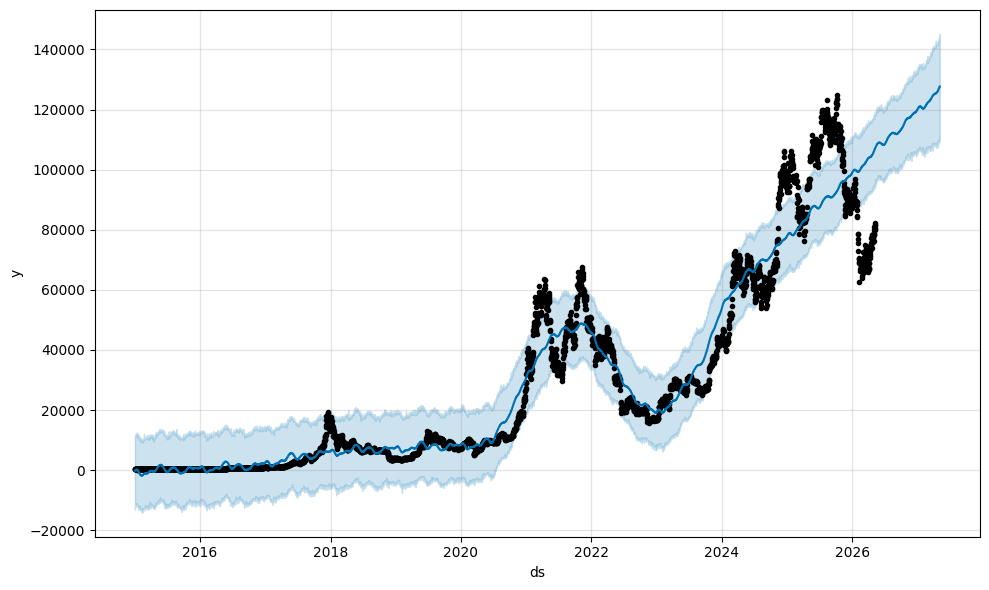

In [73]:
model.plot(tahmin);

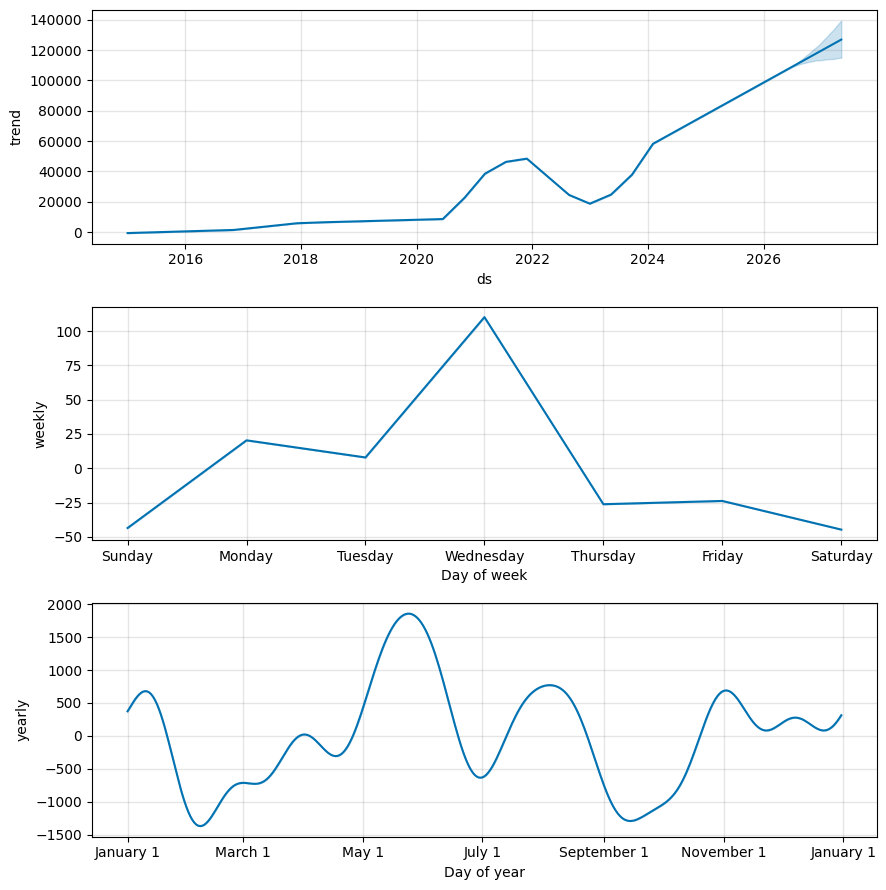

In [74]:
model.plot_components(tahmin);